# 1.3. DataPrep: Cell viability

### 📘 Overview

This notebook processes raw viability assay data and performs dose–response curve fitting to estimate the IC₁₀ value (concentration causing ≥10% viability reduction) for each compound.

**Inputs**  
Raw viability assay data across multiple doses  

**Output**  
A CSV file containing IC₁₀ estimates per compound  

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import dilimap as dmap

In [2]:
dmap.logging.print_version()

Running dilimap 1.0.2 (python 3.10.16) on 2025-06-29 15:27.


## Load raw data

In [2]:
df = dmap.s3.read('compound_cell_viability_raw.csv')

Package: s3://dilimap/public/data. Top hash: f4e2979a3d


In [3]:
df.tail()

,Dose_uM,Raw Data Result,Result,Plate Name,Location
Compound,,,,,
Trientine Hydrochloride,0.0025,0.4117,88.014,C2_M1_T3,G05
Trientine Hydrochloride,0.0025,0.4104,88.052,C2_M1_T3,G06
Pyrimethamine,0.0025,0.4312,87.446,C2_M1_T3,G10
Pyrimethamine,0.0025,0.4046,88.220,C2_M1_T3,G11
Pyrimethamine,0.0025,0.5140,85.035,C2_M1_T3,G12


## Estimate IC10s

In [4]:
for k in set(df['Plate Name']):
    plate_dmso_viability = df.loc[
        (df['Plate Name'] == k) & (df.index == 'DMSO'), 'Result'
    ].mean()

    df.loc[df['Plate Name'] == k, 'viability_cutoff_IC20'] = plate_dmso_viability * 0.8
    df.loc[df['Plate Name'] == k, 'viability_cutoff_IC10'] = plate_dmso_viability * 0.9

In [5]:
df_cmpds = (
    df.groupby(['Compound'])[['viability_cutoff_IC20', 'viability_cutoff_IC10']]
    .mean()
    .round(2)
)

df_crosstab = (
    pd.crosstab(
        df.index,
        df['Dose_uM'],
        df['Result'] < df['viability_cutoff_IC20'],
        aggfunc=np.mean,
    )
    < 0.5
)
df_cmpds['MTD_IC20'] = df_cmpds.index.map((df_crosstab * df_crosstab.columns).max(1))

df_crosstab = (
    pd.crosstab(
        df.index,
        df['Dose_uM'],
        df['Result'] < df['viability_cutoff_IC10'],
        aggfunc=np.mean,
    )
    < 0.5
)
df_cmpds['MTD_IC10'] = df_cmpds.index.map((df_crosstab * df_crosstab.columns).max(1))

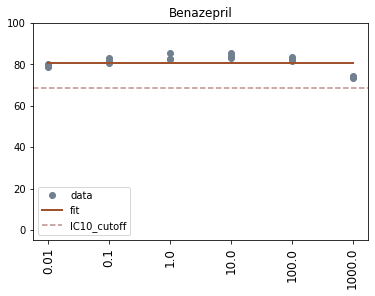

Oxcarbazepine: No optimal parameters found, using prior estimate instead
Vorinostat: No optimal parameters found, using prior estimate instead


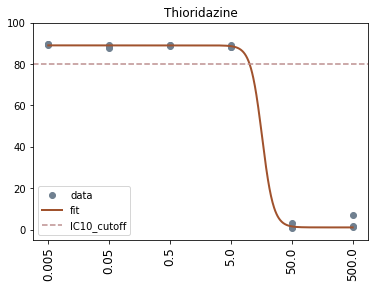

Lomustine: No optimal parameters found, using prior estimate instead


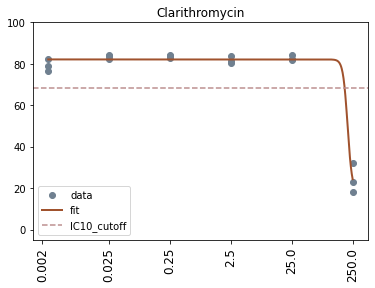

/srv/conda/envs/saturn/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


Isosorbide Dinitrate: No optimal parameters found, using prior estimate instead
Busulfan: No optimal parameters found, using prior estimate instead


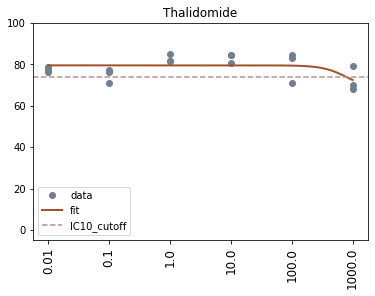

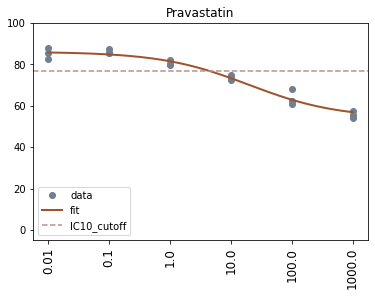

/srv/conda/envs/saturn/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


Levetiracetam: No optimal parameters found, using prior estimate instead


/srv/conda/envs/saturn/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/srv/conda/envs/saturn/lib/python3.9/site-packages/numpy/core/function_base.py:151: RuntimeWarning: invalid value encountered in multiply
  y *= step
/srv/conda/envs/saturn/lib/python3.9/site-packages/numpy/core/function_base.py:161: RuntimeWarning: invalid value encountered in add
  y += start


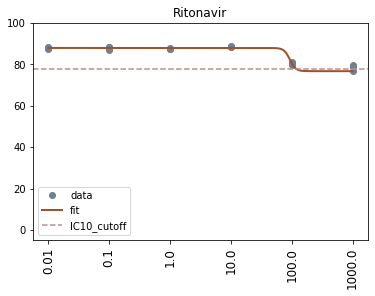

/srv/conda/envs/saturn/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


Carbamazepine: No optimal parameters found, using prior estimate instead
Felbamate: No optimal parameters found, using prior estimate instead


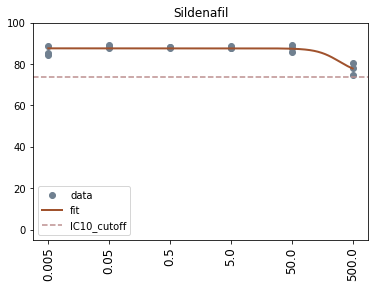

Saxagliptin: No optimal parameters found, using prior estimate instead
Lamotrigine: No optimal parameters found, using prior estimate instead


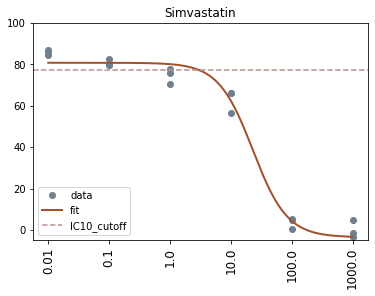

Acarbose: No optimal parameters found, using prior estimate instead
Zonisamide: No optimal parameters found, using prior estimate instead


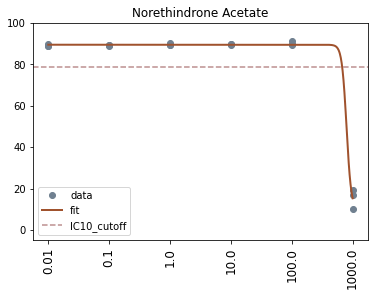

/srv/conda/envs/saturn/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


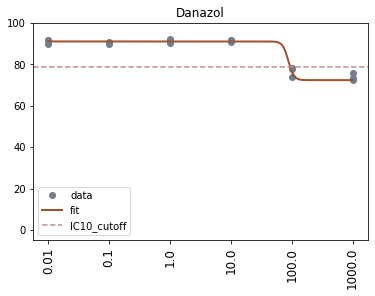

Ketorolac: No optimal parameters found, using prior estimate instead


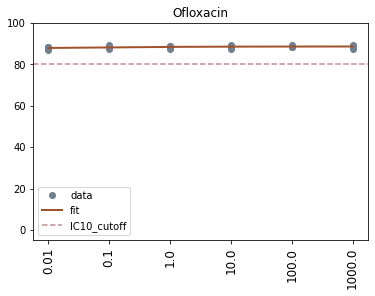

Valproic acid: No optimal parameters found, using prior estimate instead
Sulfacarbamide: No optimal parameters found, using prior estimate instead


In [39]:
from scipy.optimize import curve_fit


def plot_curve_fit(x, y, popt=None, ic10=None, title=None):
    plt.plot(x, y, 'o', color='slategrey', markersize=6, label='data')

    ## errorbar
    # df_groupby = pd.DataFrame([x.values,y.values], index=['x', 'y']).T.groupby('x')
    # plt.errorbar(df_groupby.mean().index, df_groupby['y'].mean(), yerr=2*df_groupby['y'].std(), ecolor='navy', elinewidth=2, fmt='none')

    if popt is not None:
        xlin = np.linspace(x.min(), x.max(), 1000)
        fit = sigmoid(xlin, *popt)
        plt.plot(xlin, fit, 'sienna', lw=2, label='fit')

    if ic10 is not None:
        plt.axhline(ic10, linestyle='--', color='rosybrown', label='IC10_cutoff')

    plt.ylim(-5, 100)
    plt.legend(loc='lower left')
    plt.title(title)

    xticks = np.round(10 ** np.arange(x.min(), x.max() + 1), 3)
    plt.xticks(ticks=np.log10(xticks), labels=xticks, fontsize=12, rotation=90)

    plt.show()


for cmpd in list(set(df.index)):
    ## prepare data

    df1 = df[df.index == cmpd]

    x = np.log10(df1['Dose_uM'])
    y = np.clip(df1['Result'], 0, 100)
    y = df1['Result']

    ymax = max(y)
    ymin = min(y[x == x.max()])
    xmid = np.median(x)
    ic10 = df1['viability_cutoff_IC10'].mean()

    ## curve fit

    def sigmoid(x, L, x0, k):
        y = L / (1 + np.exp(k * (x - x0))) + ymin
        return y

    def sigmoid_fit(x, y, p0):
        return curve_fit(sigmoid, x, y, p0, method='dogbox')

    try:
        p0 = [ymax, xmid, 1]
        popt, _ = sigmoid_fit(x, y, p0)
    except Exception:
        try:
            p0 = [ymax, xmid * 2, 1]
            popt, _ = sigmoid_fit(x, y, p0)
        except Exception:
            try:
                y_noclip = df1['Result']  # without clipping
                p0 = [ymax, xmid, 1]
                popt, _ = sigmoid_fit(x, y_noclip, p0)
            except Exception:
                try:
                    p0 = [max(ymax - ymin, 0), xmid, 1]
                    popt, _ = sigmoid_fit(x, y, p0)
                except Exception:
                    print(
                        f'{cmpd}: No optimal parameters found, using prior estimate instead'
                    )
                    popt = p0

    ## estimate IC10

    xlin = np.linspace(x.min(), x.max(), 1000)
    ylin = sigmoid(xlin, *popt)

    for cutoff in ['viability_cutoff_IC10', 'viability_cutoff_IC20']:
        idx_tox = ylin < df1[cutoff].mean()
        df_cmpds.loc[cmpd, f'{cutoff[-4:]}_uM'] = (
            '{:.2f}'.format(10 ** xlin[idx_tox].min()) if sum(idx_tox) > 0 else np.nan
        )

    ## viability curve examples

    # if cmpd in ['Febuxostat', 'Perphenazine', 'Oxcarbazepine']:
    #    plot_curve_fit(x, y, popt, ic10, title=cmpd)

    # list of cmpds we wanted to double-check with wetlab team
    if cmpd in [
        'Clarithromycin',
        'Benazepril',
        'Danazol',
        'Norethindrone Acetate',
        'Ofloxacin',
        'Pravastatin',
        'Ritonavir',
        'Sildenafil',
        'Simvastatin',
        'Thalidomide',
        'Thioridazine',
    ]:
        plot_curve_fit(x, y, popt, ic10, title=cmpd)

In [8]:
# Manual annotations pulled form Dotmatics

df.loc['AKN-028'] = {'MTD_IC10': 50, 'IC10_uM': 500}
df.loc['BMS-986142'] = {'MTD_IC10': 100, 'IC10_uM': 1000}
df.loc['Evobrutinib'] = {'MTD_IC10': 50, 'IC10_uM': 500}
df.loc['TAK-875'] = {'MTD_IC10': 50, 'IC10_uM': 200}
df.loc['Ibrutinib'] = {'MTD_IC10': 10, 'IC10_uM': 100}
df.loc['Orelabrutinib'] = {'MTD_IC10': 100, 'IC10_uM': 1000}
df.loc['Remibrutinib'] = {'MTD_IC10': np.nan, 'IC10_uM': np.nan}
df.loc['Rilzabrutinib'] = {'MTD_IC10': 10, 'IC10_uM': 100}
df.loc['Ruxolitinib'] = {'MTD_IC10': np.nan, 'IC10_uM': np.nan}
df.loc['Tofacitinib'] = {'MTD_IC10': np.nan, 'IC10_uM': np.nan}
df.loc['Upadacitinib'] = {'MTD_IC10': np.nan, 'IC10_uM': np.nan}

## Push file to S3

In [12]:
# dmap.s3.write(df, 'compound_cell_viability_IC10.csv')

Package: s3://dilimap/public/data. Top hash: d3f70822ce


Copying objects: 100%|█████████████████████| 12.9k/12.9k [00:00<00:00, 13.7kB/s]


Package public/data@e5bf3de pushed to s3://dilimap
Run `quilt3 catalog s3://dilimap/` to browse.
Successfully pushed the new package
